In [23]:
import xarray as xr
import arviz as az
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#from fit_trajectories import gof_trajectories
from scipy.stats import spearmanr, pearsonr

col_m = sns.color_palette("Dark2")  
mod_color_dict = {"Basic": col_m[7],"Rep_M": col_m[1], "Rep_Z": col_m[4], "Rep_V": col_m[2]} 
model_order = ["Basic", "Rep_M", "Rep_Z"]
sc = "all"

## join param results datasets

In [24]:
# join datasets
dsm = xr.load_dataset(f"../results/results_summary/Rep_M/params_results.nc")
dsz = xr.load_dataset(f"../results/results_summary/Rep_Z/params_results.nc")

traj_m = xr.load_dataset(f"../results/results_summary/Rep_M/simulation_results.nc").mean(dim="source")
traj_z = xr.load_dataset(f"../results/results_summary/Rep_Z/simulation_results.nc").mean(dim="source")

dsm = dsm.expand_dims(model=["M"])
dsz = dsz.expand_dims(model=["Z"])

traj_m = traj_m.expand_dims(model=["M"])
traj_z = traj_z.expand_dims(model=["Z"])

ds = xr.concat([dsm, dsz], dim="model")
traj = xr.concat([traj_m, traj_z], dim="model")

# choose best model by BIC --> also check for R hat??
gof_M = pd.read_csv("../results/results_summary/Rep_M/goodness_of_fit_summary.csv")[["gene_id", "BIC"]].rename(columns={"BIC":"BIC_M"}).set_index("gene_id")
gof_Z = pd.read_csv("../results/results_summary/Rep_Z/goodness_of_fit_summary.csv")[["gene_id", "BIC"]].rename(columns={"BIC":"BIC_Z"}).set_index("gene_id")
gof = gof_M.join(gof_Z, how="left").reset_index()
gof["decay_mode"] = np.where(gof["BIC_M"] == gof["BIC_Z"], "0", "")
gof["decay_mode"] = np.where(gof["BIC_M"] < gof["BIC_Z"], "M", "Z") # 1 = M preferred, -1 = Z preferred
gof["dBIC"] = abs(gof["BIC_M"] - gof["BIC_Z"])
gof["significant"] = np.where(gof["dBIC"] > 6, True, False) # strong model evidence: dBIC > 6
gof = gof.set_index("gene_id")
gof.index.name = "ensembl_gene_id"

# decay_mode DataArray
selection_da = xr.DataArray(gof["decay_mode"],dims=["ensembl_gene_id"],coords={"ensembl_gene_id": gof.index},)
ds_selected = ds.sel(model=selection_da, ensembl_gene_id=ds.ensembl_gene_id)

traj_selected = traj.sel(model=selection_da, ensembl_gene_id=traj.ensembl_gene_id)

# assing new param for model selection
# map M -> 1, Z -> 0
selection_num = gof["decay_mode"].map({"M": 1, "Z": 0})
selection_num_da = xr.DataArray(selection_num, dims=["ensembl_gene_id"], coords={"ensembl_gene_id": gof.index},).reindex(ensembl_gene_id=ds_selected.ensembl_gene_id)
ds_selected["decay_mode"] = selection_num_da

param_cluster_label = xr.load_dataset("results/joint_params_results_labels.nc").cluster_label

traj_selected["supercluster"] = param_cluster_label
print(traj_selected.supercluster.isnull().sum().item())  # any unmatched genes?
traj_selected = traj_selected.rename_vars({"y":"tpm"})
peak_idx = np.argmax(traj_selected["tpm"].values, axis=1)  # one index per gene
peak_time_values = traj_selected["time"].values[peak_idx]   # or traj_selected.time.values[np.arange(n), peak_idx] if time varies per-row

ds_selected["peak_time"] = ("ensembl_gene_id", peak_time_values)
ds_selected["maternal_half_life"] = np.log(2) / ds_selected["delta_m"]
ds_selected["repression_ratio"] = ds_selected["beta"] / ds_selected["alpha"]
ds_selected["y0"] = traj_selected.sel(time=0).M

# accepted genes
acc_genes = pd.read_csv("../acc_genes.csv").gene_id.values
gof = gof.reset_index()
gof = gof[gof["ensembl_gene_id"].isin(acc_genes)]
ds_selected = ds_selected.sel(ensembl_gene_id=acc_genes)
traj_selected = traj_selected.sel(ensembl_gene_id=acc_genes)

# save dataset
ds_selected.to_netcdf("joint_params_results.nc")
traj_selected.to_netcdf("joint_simulation_results.nc")
gof.to_csv("prefered_decay_mode.csv", index=False)


traj_selected ## TODO: all labels
ds_selected

5256


C:\Users\mgrho\AppData\Local\Temp\ipykernel_12428\4092623843.py:62: SerializationWarning: saving variable supercluster with floating point data as an integer dtype without any _FillValue to use for NaNs
  traj_selected.to_netcdf("joint_simulation_results.nc")


<xarray.Dataset>
Dimensions:             (ensembl_gene_id: 16184)
Coordinates:
    model               (ensembl_gene_id) object 'M' 'Z' 'Z' 'M' ... 'Z' 'M' 'Z'
  * ensembl_gene_id     (ensembl_gene_id) object 'ENSDARG00000000002' ... 'EN...
    time                float64 0.0
Data variables:
    alpha               (ensembl_gene_id) float64 0.6719 39.55 ... 2.1 0.5743
    beta                (ensembl_gene_id) float64 1.197 2.093 ... 0.2943 1.095
    delta_m             (ensembl_gene_id) float64 0.06211 1.571 ... 0.5718 1.453
    sigma_y             (ensembl_gene_id) float64 0.3602 0.2981 ... 0.2917
    t_rep               (ensembl_gene_id) float64 34.1 2.007 ... 4.402 10.79
    t_zga               (ensembl_gene_id) float64 12.48 0.4106 ... 6.045 0.5634
    t_reg               (ensembl_gene_id) float64 46.58 2.418 ... 10.45 11.35
    decay_mode          (ensembl_gene_id) int64 1 0 0 1 0 0 0 ... 1 1 0 1 0 1 0
    peak_time           (ensembl_gene_id) float64 120.0 3.0 3.0 ... 10.32 120.0
    maternal_half_life  (ensembl_gene_id) float64 11.16 0.4412 ... 1.212 0.4771
    repression_ratio    (ensembl_gene_id) float64 1.782 0.05293 ... 0.1402 1.907
    y0                  (ensembl_gene_id) float64 0.2773 5.205 ... 0.0 1.089

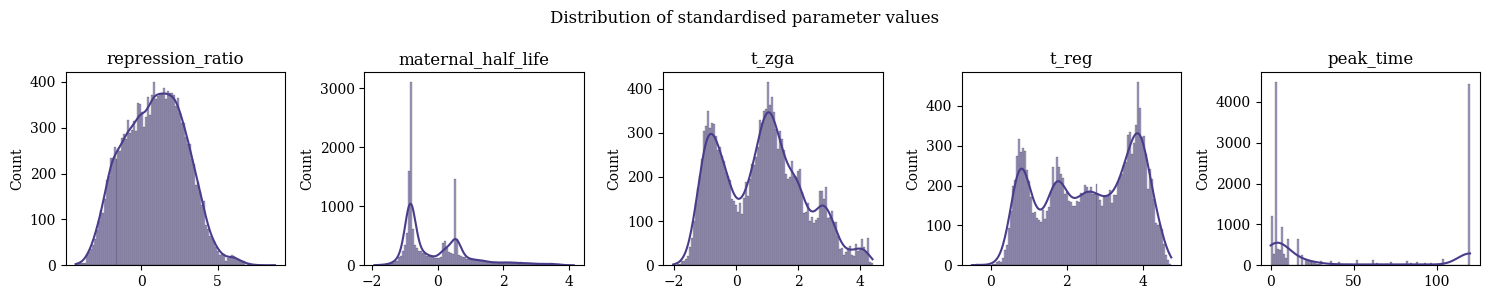

In [25]:
# plot params distribution
params = [ "alpha", "beta", "delta_m", "t_zga", "t_reg"]
params = ["repression_ratio", "maternal_half_life", "t_zga", "t_reg", "peak_time" ]
#params = [ "alpha", "beta", "delta_m",  "t_zga", "t_reg", "peak_time"]

model ="joint"
fig, ax = plt.subplots(1, len(params), figsize=(3*len(params), 3)) 

ds = xr.load_dataset(f"joint_params_results.nc")
traj = xr.load_dataset(f"joint_simulation_results.nc")

ds["repression_ratio"] = ds.alpha.clip(min=1e-5)
ds["alpha"] = ds.alpha.clip(min=1e-5)
ds["beta"] = ds.beta.clip(min=1e-5)
ds["delta_m"] = ds.delta_m.clip(min=1e-5)
ds["t_zga"] = ds.t_zga.clip(max=120)
ds["t_reg"] = ds.t_reg.clip(max=120)

ds["repression_ratio"] = np.log(ds["repression_ratio"])
ds["maternal_half_life"] = np.log(ds["maternal_half_life"])
ds["t_zga"] = np.log(ds["t_zga"])
ds["t_reg"] = np.log(ds["t_reg"])
x = ds

# u = x.mean()
# s= x.std()
# z_x = (x-u)/s

for i, par in enumerate(params):
    sns.histplot(x[par], ax=ax[i], kde=True, bins=100, color="darkslateblue",)
    #sns.kdeplot(z_x[par], ax=ax[n][i], color=mod_color_dict[model], )

    ax[i].set(title= par)
# ax[0].text(0.01,1.1, s=f"{model}", transform=ax[n][0].transAxes, bbox=dict(facecolor=mod_color_dict[model], alpha=0.5))
# ax[3].axvline(x=np.log(3), c="k", ls="--")
# ax[4].axvline(x=np.log(3), c="k", ls="--")
plt.suptitle(f"Distribution of standardised parameter values")
plt.tight_layout()
plt.savefig(f"figs/joint_param_dist.png", dpi=300)
plt.show()

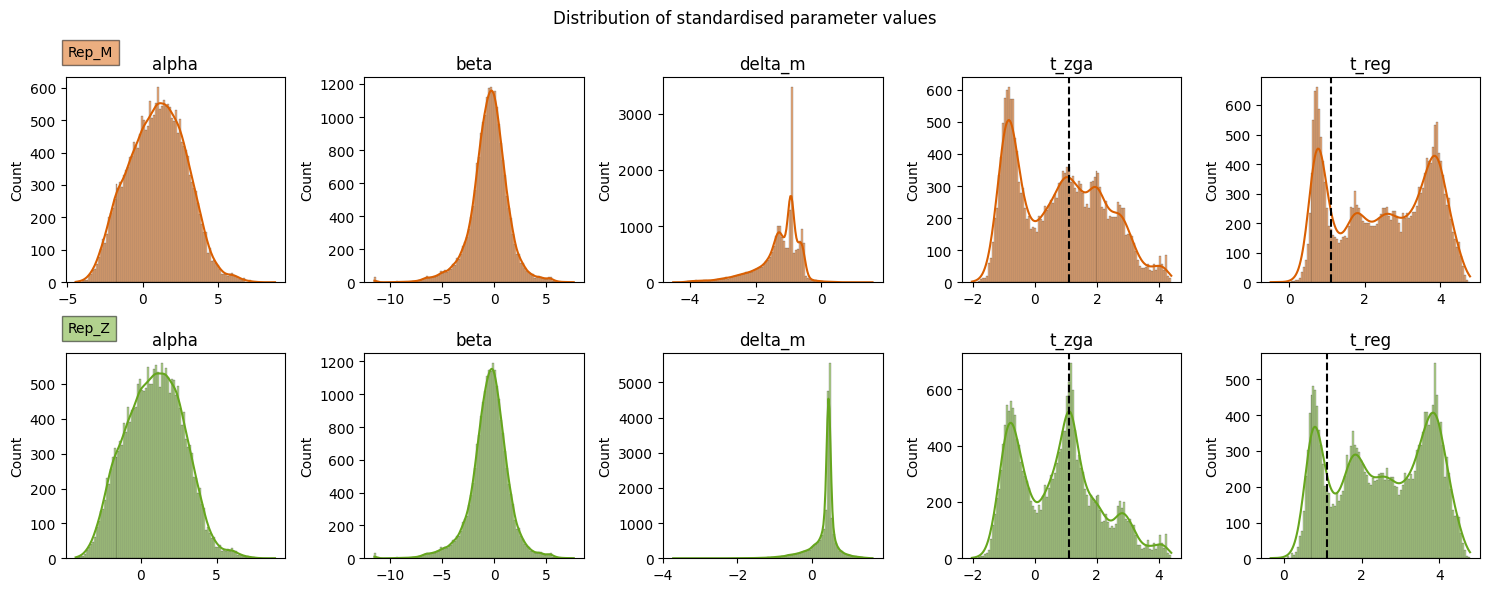

In [4]:
# plot params distribution
params = [ "alpha", "beta", "delta_m", "t_zga", "t_reg"]
#params = [ "alpha", "beta", "delta_m",  "t_zga", "t_reg", "peak_time"]

models = ["Rep_M", "Rep_Z"]
fig, ax = plt.subplots(len(models), len(params), figsize=(3*len(params), 3*(len(models)))) 

for n, model in enumerate(models):
    ds = xr.load_dataset(f"../results/results_summary/{model}/params_results.nc")
    traj = xr.load_dataset(f"../results/results_summary/{model}/simulation_results.nc").mean(dim="source")

    ds["alpha"] = ds.alpha.clip(min=1e-5)
    ds["beta"] = ds.beta.clip(min=1e-5)
    ds["delta_m"] = ds.delta_m.clip(min=1e-5)
    ds["t_zga"] = ds.t_zga.clip(max=120)
    ds["t_reg"] = ds.t_reg.clip(max=120)

    x = np.log(ds)

    x["peak_time"] = traj.time[np.argmax(traj.y.values, axis=1)]

    u = x.mean()
    s= x.std()

    z_x = (x-u)/s

    for i, par in enumerate(params):
        sns.histplot(x[par], ax=ax[n][i], color=mod_color_dict[model], kde=True, bins=100)
        #sns.kdeplot(z_x[par], ax=ax[n][i], color=mod_color_dict[model], )

        ax[n][i].set(title= par)
    ax[n][0].text(0.01,1.1, s=f"{model}", transform=ax[n][0].transAxes, bbox=dict(facecolor=mod_color_dict[model], alpha=0.5))
    ax[n][3].axvline(x=np.log(3), c="k", ls="--")
    ax[n][4].axvline(x=np.log(3), c="k", ls="--")
plt.suptitle(f"Distribution of standardised parameter values")
plt.tight_layout()
plt.savefig(f"figs/param_dist.png", dpi=300)
plt.show()

Number of genes in dataset: 16184


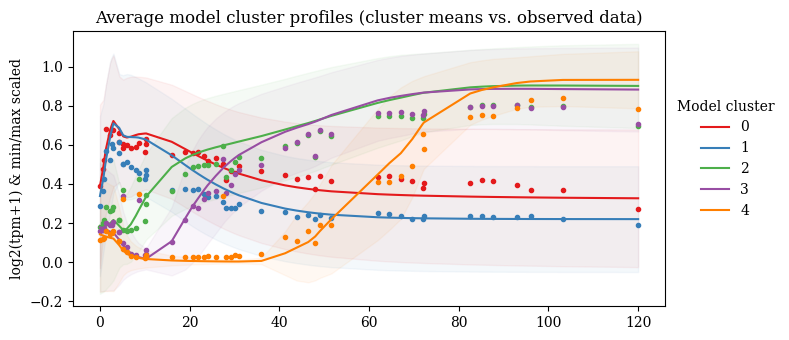

,supercluster,RMSE,r2,spearmanr,pearsonr
0,0,0.053279,0.710032,0.943818,0.938481
1,1,0.091657,0.450049,0.951981,0.955757
2,2,0.096531,0.799873,0.953806,0.968353
3,3,0.091834,0.882756,0.959856,0.975815
4,4,0.098610,0.863234,0.855366,0.963178


In [26]:
# parameter

def minmax(curve):
    mn = curve.min("time")
    mx = curve.max("time")
    return (curve - mn) / (mx - mn)

def zscore(curve):
    sd = curve.std("time")
    return (curve - curve.mean("time")) / sd

def rmse(a, b):
    mask = ~np.isnan(a) & ~np.isnan(b)
    return np.sqrt(np.mean((a[mask] - b[mask])**2)).item()

def r2(y_true, y_pred):
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    ss_res = np.sum((y_true[mask] - y_pred[mask])**2)
    ss_tot = np.sum((y_true[mask] - np.mean(y_true[mask]))**2)
    return (1 - ss_res/ss_tot).item()

from scipy.stats import spearmanr, pearsonr
sc = "all"
ds = xr.load_dataset(f"joint_simulation_results.nc")
labels =  xr.load_dataset("results/joint_params_superclusters_labels.nc")
obs = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc").mean(dim="source").sel(ensembl_gene_id = ds.ensembl_gene_id.values)
#obs = cluster_data.mean(dim="source")

ds["tpm"] = np.log2(ds.tpm + 1)
ds["tpm"] = (ds.tpm - ds.tpm.mean(dim=("time"))) / ds.tpm.std(dim=("time")) #z-score

obs["tpm"] = np.log2(obs.tpm + 1)
obs["tpm"] = (obs.tpm - obs.tpm.mean(dim=("time"))) / obs.tpm.std(dim=("time")) #z-score

print(f"Number of genes in dataset: {len(labels.cluster_label.ensembl_gene_id)}")

gof = []
#cluster_map = {0:"SD", 1:"DSD", 2:"SU", 3:"DSU"}
colors = sns.color_palette("Set1", 6)

plt.figure(figsize=(8,3.5))
for c in np.unique(labels.cluster_label.values):

    gene_ids = labels['ensembl_gene_id'][labels['cluster_label'] == c].values

    obs_c = obs.sel(ensembl_gene_id=gene_ids)
    obs_c_mean = minmax(obs_c.tpm).mean(dim=("ensembl_gene_id"))
    obs_c_std = minmax(obs_c.tpm).std(dim=("ensembl_gene_id",))

    ds_c = ds.sel(ensembl_gene_id=gene_ids)
    ds_c_mean = minmax(ds_c.tpm).mean(dim=("ensembl_gene_id"))
    ds_c_std = minmax(ds_c.tpm).std(dim=("ensembl_gene_id",))

    plt.plot(ds_c_mean.time, ds_c_mean, "-", c=colors[c], label=c)
    plt.plot(obs_c_mean.time, obs_c_mean, ".", c=colors[c], )

    plt.fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=colors[c])

    gof.append({"supercluster":c, "RMSE":rmse(obs_c_mean, ds_c_mean),  "r2":r2(obs_c_mean, ds_c_mean),  
                "spearmanr": spearmanr(obs_c_mean, ds_c_mean)[0], "pearsonr":pearsonr(obs_c_mean, ds_c_mean)[0]})
   
pd.DataFrame(gof).to_excel("cluster_validation.xlsx")

#plt.xlim(0, 20)
plt.title("Average model cluster profiles (cluster means vs. observed data)")
plt.ylabel("log2(tpm+1) & min/max scaled")
plt.legend(loc=(1.01, 0.3), frameon=False, title="Model cluster")
plt.tight_layout()
plt.savefig("figs/param_cluster_validation.png", dpi=300)
plt.show()
pd.DataFrame(gof)

In [27]:
cluster_names = {0: "pre-ZGA SD1",
                 1: "pre-ZGA SD2",
                 2: "ZGA SU",
                 3: "post-ZGA SU",
                 4: "late post-ZGA SU",}

In [6]:
cluster_names = {0: "pre-ZGA SD1",
                 1: "pre-ZGA SD2",
                 2: "pre-ZGA SD3",
                 3: "SU1",
                 4: "SU2",
                 5: "SU3",}

### heatmap

16184 16184


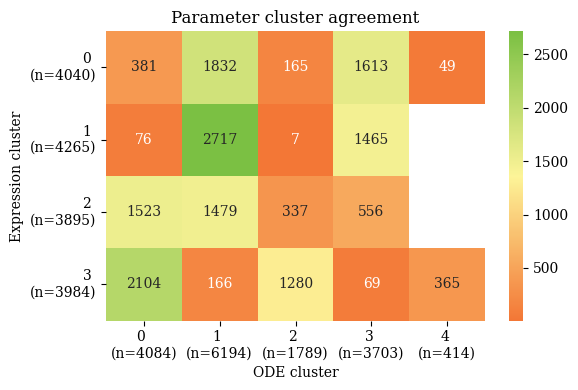

In [28]:
ds0 = xr.load_dataset(f"results/{sc}_gene_cluster_annotation_minmax.nc").supercluster
ds1 = xr.load_dataset("results/joint_params_results_labels.nc").cluster_label

ds0 = ds0.sel(ensembl_gene_id = ds1.ensembl_gene_id.values)

cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True)

df0 = pd.DataFrame({"ensembl_gene_id": ds0.ensembl_gene_id.values, "Expression cluster":ds0.values})
df1 = pd.DataFrame({"ensembl_gene_id": ds1.ensembl_gene_id.values, "ODE cluster":ds1.values})
df = df0.merge(df1, on="ensembl_gene_id", how="inner", validate="one_to_one")

print(len(df0), len(df1))

matr = df.groupby(["Expression cluster", "ODE cluster"]).count().reset_index()
df_plot = matr.pivot(index="Expression cluster", columns=["ODE cluster"], values="ensembl_gene_id")
import seaborn as sns
row_totals = df.groupby("Expression cluster")["ensembl_gene_id"].count()
col_totals = df.groupby("ODE cluster")["ensembl_gene_id"].count()

ylabels = [f"{idx} \n(n={row_totals.loc[idx]})" for idx in df_plot.index]
xlabels = [f"{col} \n(n={col_totals.loc[col]})" for col in df_plot.columns]

fig, ax = plt.subplots(figsize=(6, 4),)
sns.heatmap(df_plot,annot=True, cmap=cmap, fmt=".0f")
ax.set_yticklabels(ylabels, rotation=0)
ax.set_xticklabels(xlabels, rotation=0)
plt.title(f"Parameter cluster agreement")
plt.tight_layout()
plt.savefig("figs/cluster_agreement_heatmap_Rep_jointODE.png", dpi=300)

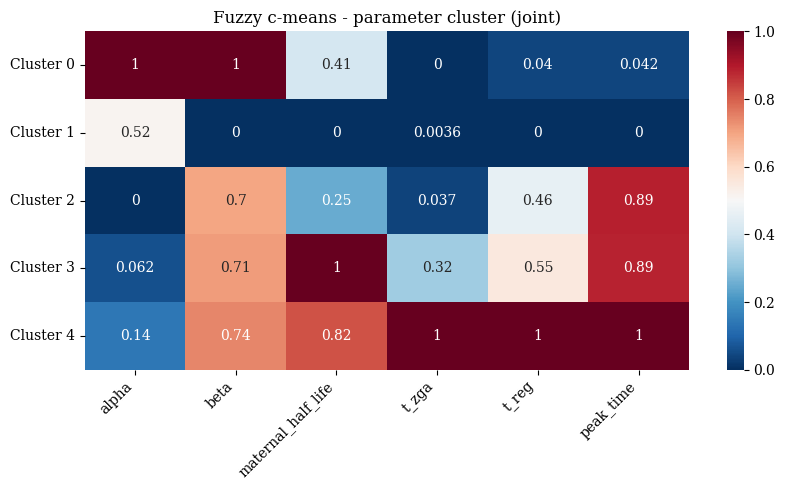

In [29]:
def plot_cluster_centers(centers_std_da, dataset_name):
    """
    Heatmap of standardized cluster centers: one row per cluster, one
    column per parameter. Replaces the trajectory line plot from the
    time-series version, since there's no time axis here.
    """

    da = centers_std_da["cluster_centers_standardized"]  # dims: (cluster, feature)

    # Min-max: (x - min) / (max - min), computed along "cluster" for each feature
    dmin = da.min(dim="cluster")
    dmax = da.max(dim="cluster")
    da_minmax = (da - dmin) / (dmax - dmin)

    centers_std_da["cluster_centers_minmax"] = da_minmax

    k = centers_std_da.sizes["cluster"]
    features = centers_std_da.feature.values

    fig, ax = plt.subplots(figsize=(1.1 * len(features) + 2, 0.6 * k + 2))
    sns.heatmap(data=centers_std_da.cluster_centers_minmax, cmap="RdBu_r", annot=True)

    ax.set_xticklabels(features, rotation=45, ha="right")
    ax.set_yticklabels([f"Cluster {c}" for c in range(k)], rotation=0)

    ax.set_title(f"Fuzzy c-means - parameter cluster ({dataset_name})")
    fig.tight_layout()
    fig.savefig(f"figs/FCM_param_cluster_center_{dataset_name}.png", dpi=300)
    plt.show(fig)

centers_std_da = xr.load_dataset(f"results/joint_params_superclusters_centers.nc")
plot_cluster_centers(centers_std_da, "joint")

### Sankey diagramm

In [30]:
from pySankey.sankey import sankey
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

col_c = sns.color_palette("Set1", n_colors=6)  
cluster_color_dict = {str(0): "red", str(1): "blue", str(2): "green", str(3): "purple",  str(4): "orange",str(5): "yellow",}

def cluster_agreement(ds1, ds2, algo1, algo2):

   df1 = pd.DataFrame({"ensembl_gene_id": ds1.ensembl_gene_id.values, "cluster":ds1.values})
   df2 = pd.DataFrame({"ensembl_gene_id": ds2.ensembl_gene_id.values, "cluster2":ds2.values})

   dup1 = df1["ensembl_gene_id"].duplicated().sum()
   dup2 = df2["ensembl_gene_id"].duplicated().sum()
   if dup1 or dup2:
      print(f"Warning: {dup1} duplicate ids in ds1, {dup2} duplicate ids in ds2")

   df = df1.merge(df2, on="ensembl_gene_id", how="inner", validate="one_to_one")

   df["agreement"] = (df["cluster"] == df["cluster2"])
   df = df.dropna(subset=["cluster", "cluster2"])
   df = df.sort_values(["cluster", "cluster2"], ascending=False)

   sankey(left=df["cluster"].astype(str), right=df["cluster2"].astype(str), 
         aspect=20, fontsize=12,
         figure_name=f"figs/cluster_agreement_{algo1}_{algo2}",
         colorDict=cluster_color_dict
         )

   # Get current figure
   fig = plt.gcf()
   fig.set_size_inches(6, 6)
   fig.set_facecolor("w")
   plt.title(f"Cluster Changes \n({algo1} → {algo2})")
   fig.savefig(f"figs/cluster_agreement_{algo1}_{algo2}.png", bbox_inches="tight", dpi=300)

   agree = df["agreement"].sum() / len(df) * 100
   print(f"Cluster agreement: {agree:.2f} %")

   return df

Cluster agreement: 21.65 %


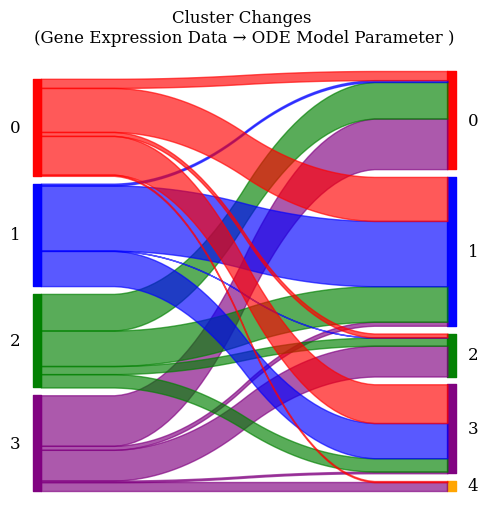

In [31]:
algo1 = "Gene Expression Data"
ds1 = xr.load_dataset(f"results/{sc}_gene_cluster_annotation_minmax.nc").supercluster

algo2 = "ODE Model Parameter "
ds2 = xr.load_dataset("results/joint_params_results_labels.nc").cluster_label

df = cluster_agreement(ds1, ds2, algo1, algo2)

## Clustering

In [ ]:
# Clustering
import xarray as xr
import numpy as np
import pandas as pd
import fuzzy_clustering1 as fc

traj120 = xr.load_dataarray(f"results/{sc}_normalized_trajectories_120_minmax.nc")
membership120, labels120, centers120 = fc.cluster_dataset(traj120, f"results/early_superclusters", dataset_name="supercluster", k_range=range(4, 8))

# --- reindex superclusters by increasing peak time ---
peak_times = np.argmax(centers120.values, axis=1)      # peak time index per (old) cluster
new_order = np.argsort(peak_times)              # old cluster ids, sorted by peak time
rank = np.argsort(new_order)                    # rank[old_id] = new_id

# reorder centers
centers120 = centers120.isel(cluster=new_order).assign_coords(cluster=np.arange(len(new_order)))
centers120.to_netcdf(f"results/early_superclusters_centers.nc")

labels120 = labels120.copy(data=rank[labels120.values])  # remap gene labels to new ids
labels120.to_netcdf(f"results/early_superclusters_labels.nc")
fc.plot_clusters(centers120, "EarlySuperclusters")

Selecting best K...
K=4 | stability=0.9823 +/- 0.0081, null=0.9770 | FPC=0.6521 | XB=0.3006
K=5 | stability=0.9814 +/- 0.0066, null=0.9813 | FPC=0.6008 | XB=0.3446
K=6 | stability=0.9579 +/- 0.0182, null=0.9797 | FPC=0.5514 | XB=0.8155
K=7 | stability=0.9446 +/- 0.0231, null=0.9814 | FPC=0.5227 | XB=0.7680
Number of Clusters: 4
results/early_superclusters: K=4, FPC=0.652


In [ ]:
ds = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc")
ds_clean = ds.dropna(dim="time", how="all", subset=["tpm"])
mask = ((ds_clean.tpm.max(dim="time", skipna=True) >= 1) & (ds_clean.tpm.std(("time")) > 0.05)).all(dim="source")
ds_clean = ds_clean.sel(ensembl_gene_id=mask)
ds_clean["tpm"] = np.log2(ds_clean.tpm + 1)

# Compute dynamic range of fitted trajectory in log2(TPM+1) space, before min-max scaling
dyn_range = ds_clean.tpm.max(dim=("time", "source")) - ds_clean.tpm.min(dim=("time", "source"))

MIN_LOG2_RANGE = 1.0  # e.g. >= 2-fold change; tune based on inspection below
range_mask = dyn_range >= MIN_LOG2_RANGE
trajectories_filtered = ds_clean.sel(ensembl_gene_id=range_mask)

print(f"Kept {range_mask.sum().item()} / {ds_clean.sizes['ensembl_gene_id']} genes "
      f"after dynamic range filter (>= {MIN_LOG2_RANGE} log2 units)")

import matplotlib.pyplot as plt
dyn_range.plot.hist(bins=500)
plt.axvline(MIN_LOG2_RANGE, color="red", linestyle="--")
plt.xlabel("log2(TPM+1) dynamic range of fitted trajectory")
plt.show()

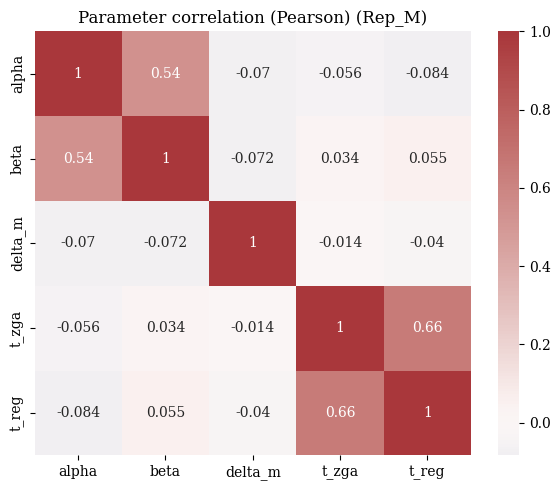

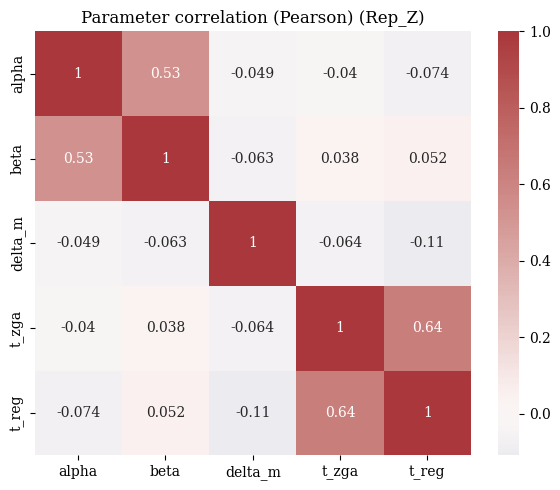

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
params = [ "alpha", "beta", "delta_m", "t_zga", "t_reg"]
models = ["Rep_M", "Rep_Z"]
for model in models:
    ds = xr.load_dataset(f"../results/results_summary/{model}/params_results.nc")
    df = ds[params].to_dataframe()
    plt.figure(figsize=(6, 5))
    sns.heatmap(df.corr(method="pearson"),    annot=True,    cmap="vlag",    center=0,)
    plt.title(f"Parameter correlation (Pearson) ({model})")
    plt.tight_layout()
    plt.show()